In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
train=pd.read_csv('train.csv',parse_dates=['date'])
test=pd.read_csv('test.csv',parse_dates=['date'])
holidays=pd.read_csv('holidays_events.csv',parse_dates=['date'])
stores=pd.read_csv('stores.csv')

In [61]:
train['day_of_week']=train['date'].dt.day_name()
order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
train['day_of_week']=pd.Categorical(train['day_of_week'],ordered=True,categories=order)
train['year']=train['date'].dt.year
train['month']=train['date'].dt.month


/tmp/ipykernel_4989/1867435331.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp_week=train.groupby(['day_of_week'])['sales'].mean()


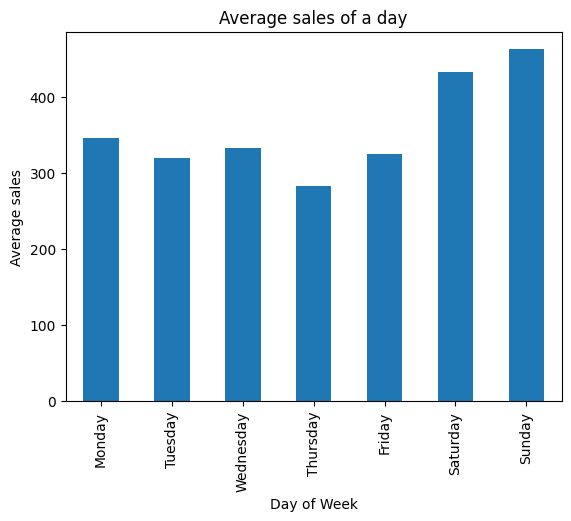

In [62]:
grp_week=train.groupby(['day_of_week'])['sales'].mean()
grp_week.plot(kind='bar',title='Average sales of a day')
plt.xlabel('Day of Week')
plt.ylabel('Average sales')
plt.show()

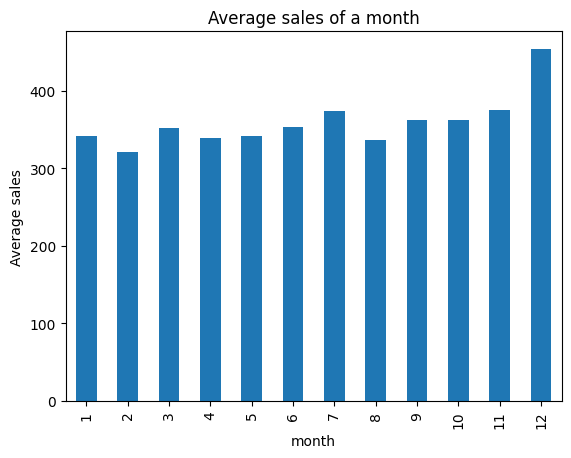

In [63]:
grp_month=train.groupby(['month'])['sales'].mean()
grp_month.plot(kind='bar',title='Average sales of a month')
plt.xlabel('month')
plt.ylabel('Average sales')
plt.show()

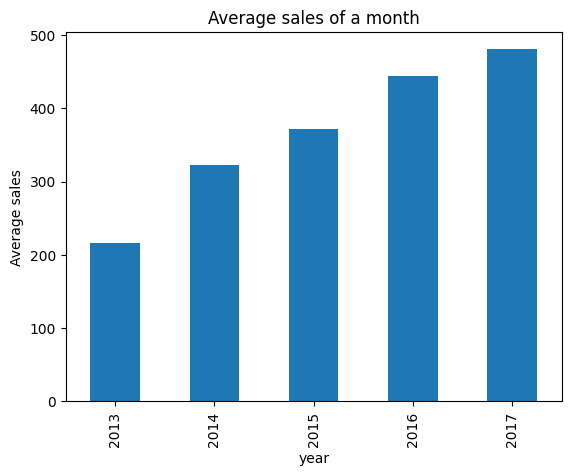

In [64]:
grp_year=train.groupby(['year'])['sales'].mean()
grp_year.plot(kind='bar',title='Average sales of a month')
plt.xlabel('year')
plt.ylabel('Average sales')
plt.show()

In [65]:
avg_sales = train.groupby('date').agg({'sales': 'mean'}).reset_index()
avg_sales['Time'] = np.arange(len(avg_sales.index))
avg_sales.head()

,date,sales,Time
0,2013-01-01,1.409438,0
1,2013-01-02,278.390807,1
2,2013-01-03,202.840197,2
3,2013-01-04,198.911154,3
4,2013-01-05,267.873244,4


Text(0, 0.5, 'Average Sales')

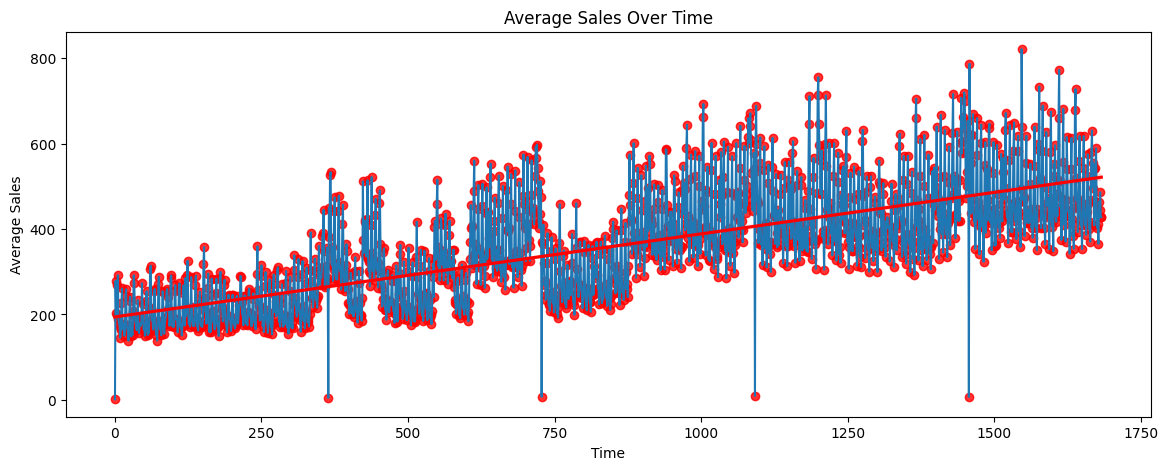

In [66]:
fig,ax=plt.subplots(figsize=(14,5))
ax.plot(avg_sales['Time'],avg_sales['sales'])
ax=sns.regplot(x='Time',y='sales',data=avg_sales,color='r')
ax.set_title('Average Sales Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Average Sales')

In [67]:
avg_sales.drop(columns='Time',inplace=True)
avg_sales.set_index('date',inplace=True)

Text(0, 0.5, 'Average Sales')

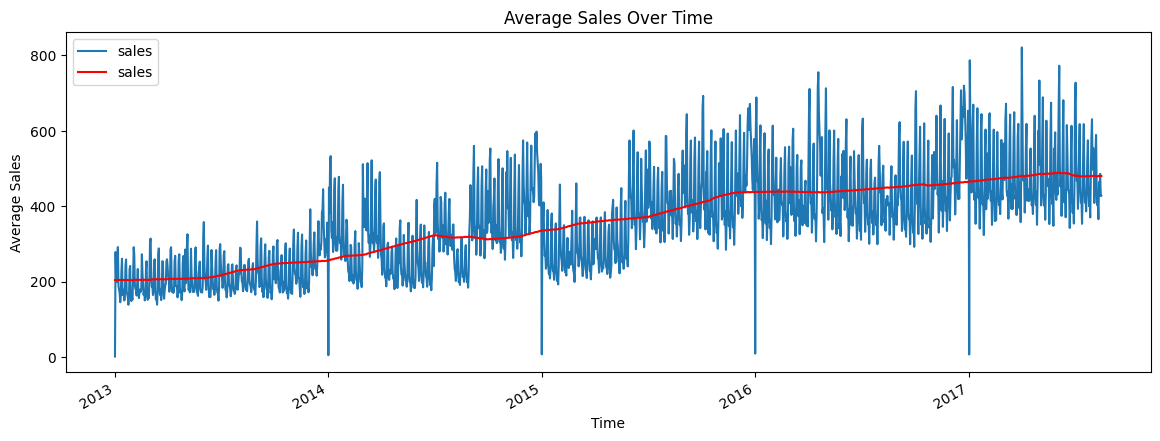

In [68]:
rolling=avg_sales.rolling(window=365,center=True,min_periods=183).mean()
fig,ax=plt.subplots(figsize=(14,5))
ax=avg_sales.plot(ax=ax)
rolling.plot(ax=ax,color='r')
ax.set_title('Average Sales Over Time')
ax.set_xlabel('Time')
ax.set_ylabel('Average Sales')


In [69]:
from statsmodels.tsa.deterministic import DeterministicProcess
dp=DeterministicProcess(index=avg_sales.index,constant=True,
                       order=1,
                       drop=True)
x=dp.in_sample()
x.head()

,const,trend
date,,
2013-01-01,1.0,1.0
2013-01-02,1.0,2.0
2013-01-03,1.0,3.0
2013-01-04,1.0,4.0
2013-01-05,1.0,5.0


In [70]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression(fit_intercept=False)
y=avg_sales['sales']
lr.fit(x,y)
trend_p=pd.Series(lr.predict(x),index=x.index)
trend_p.head()


,0
date,
2013-01-01,194.232790
2013-01-02,194.427137
2013-01-03,194.621484
2013-01-04,194.815831
2013-01-05,195.010178


Text(0.5, 1.0, 'REMOVING TREND')

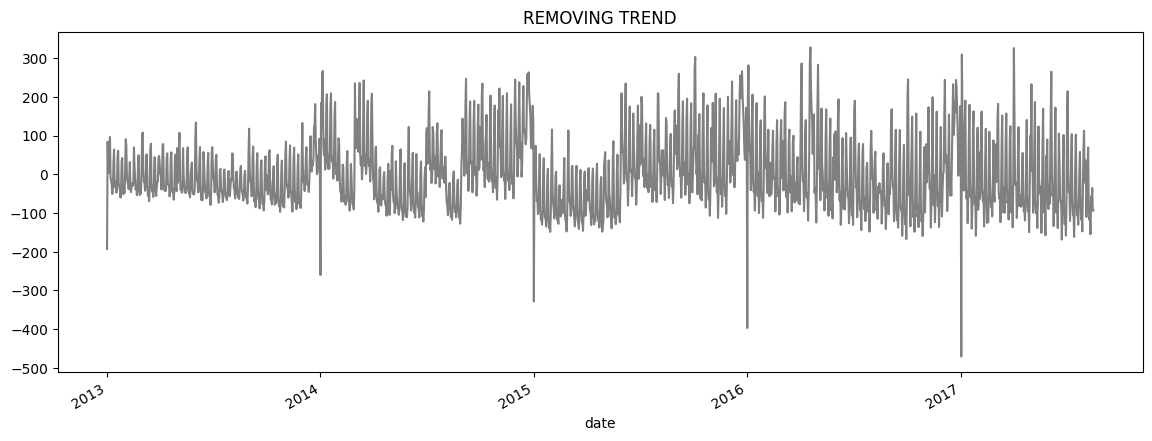

In [71]:
y_de_trended=y - trend_p
fig,ax=plt.subplots(figsize=(14,5))
ax=y_de_trended.plot(style="-",color="0.5",ax=ax)
ax.set_title('REMOVING TREND')

In [72]:
def plot_periodogram(ts, detrend='linear', ax=None, color='purple'):
    from scipy.signal import periodogram
    fs = 365.25
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color=color)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

In [73]:
avg_sales=train.groupby('date').agg({'sales':'mean'}).reset_index()
avg_sales=avg_sales.set_index('date').to_period('D')
avg_sales.head()

,sales
date,
2013-01-01,1.409438
2013-01-02,278.390807
2013-01-03,202.840197
2013-01-04,198.911154
2013-01-05,267.873244


Text(0.5, 1.0, 'PRODUCT SALES')

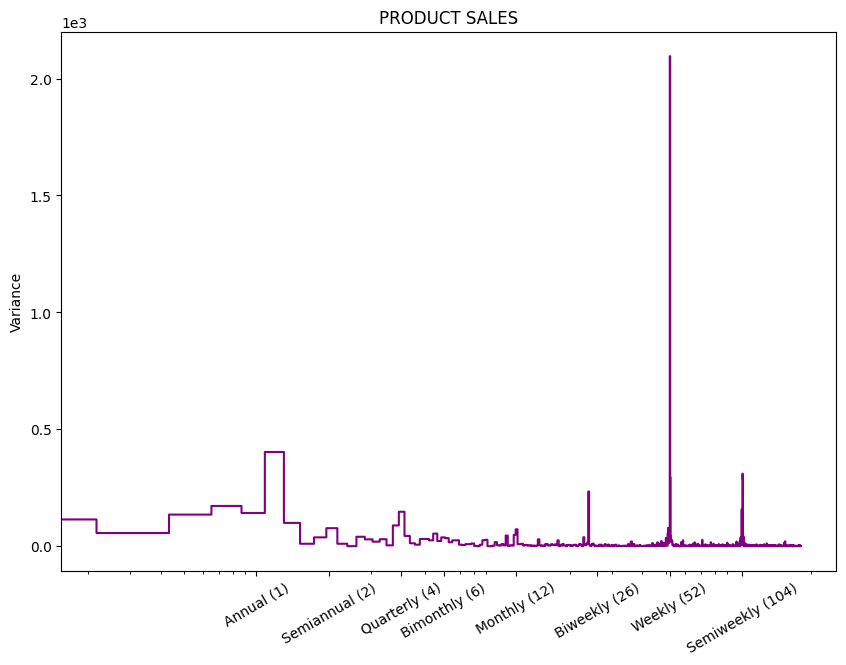

In [74]:
y=avg_sales["sales"]
fig,ax=plt.subplots(figsize=(10,7))
ax=plot_periodogram(y,ax=ax)
ax.set_title('PRODUCT SALES')

In [75]:
avg_sales['day_of_week']=avg_sales.index.to_timestamp().day_name()
avg_sales['month']=avg_sales.index.to_timestamp().month
avg_sales['year']=avg_sales.index.to_timestamp().year

In [76]:
from statsmodels.tsa.deterministic import DeterministicProcess,CalendarFourier
fourier=CalendarFourier(freq='YE',order=8)
avg_sales = avg_sales.asfreq('D') # Ensure the index has a daily frequency
dp=DeterministicProcess(
    index=avg_sales.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier],
    drop=True
)
x=dp.in_sample()
x.head()

,const,trend,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)",...,"sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)","sin(5,freq=YE-DEC)","cos(5,freq=YE-DEC)","sin(6,freq=YE-DEC)","cos(6,freq=YE-DEC)","sin(7,freq=YE-DEC)","cos(7,freq=YE-DEC)","sin(8,freq=YE-DEC)","cos(8,freq=YE-DEC)"
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2013-01-02,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.017213,0.999852,...,0.068802,0.997630,0.085965,0.996298,0.103102,0.994671,0.120208,0.992749,0.137279,0.990532
2013-01-03,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.034422,0.999407,...,0.137279,0.990532,0.171293,0.985220,0.205104,0.978740,0.238673,0.971100,0.271958,0.962309
2013-01-04,1.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.051620,0.998667,...,0.205104,0.978740,0.255353,0.966848,0.304921,0.952378,0.353676,0.935368,0.401488,0.915864
2013-01-05,1.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.068802,0.997630,...,0.271958,0.962309,0.337523,0.941317,0.401488,0.915864,0.463550,0.886071,0.523416,0.852078


In [77]:
x['is_weekend']=x.index.to_timestamp().day_name().isin(['Saturday','Sunday']).astype(int)

In [78]:
x['is_weekend']

,is_weekend
date,
2013-01-01,0
2013-01-02,0
2013-01-03,0
2013-01-04,0
2013-01-05,1
...,...
2017-08-11,0
2017-08-12,1
2017-08-13,1


In [79]:
lr1=LinearRegression(fit_intercept=False)
y=avg_sales['sales']

lr1.fit(x,y)
trend_p1=pd.Series(lr1.predict(x),index=x.index)
trend_p1.head()

,0
date,
2013-01-01,218.275163
2013-01-02,220.790599
2013-01-03,224.231106
2013-01-04,219.501866
2013-01-05,332.082864


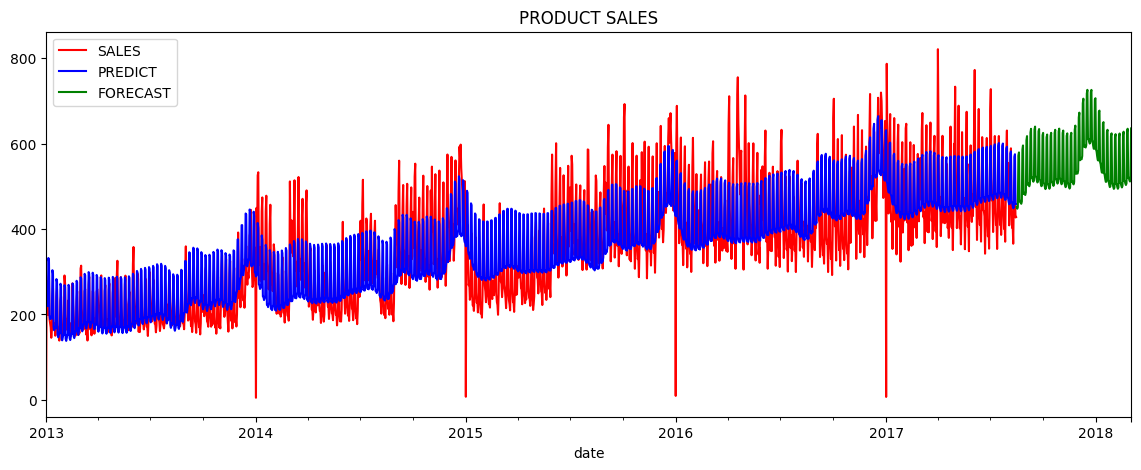

In [80]:
x_fore=dp.out_of_sample(200)
weekend_array = x_fore.index.to_timestamp().day_name().isin(['Saturday','Sunday']).astype(int)
weekend_feature = pd.Series(weekend_array, index=x_fore.index, name='is_weekend') # Convert to Series with name
x_fore = x_fore.join(weekend_feature)
y_fore=pd.Series(lr1.predict(x_fore),index=x_fore.index)
fig,ax=plt.subplots(figsize=(14,5))
y.plot(ax=ax,label='SALES',color='r') # Plot sales first, without transparency
trend_p1.plot(ax=ax,label='PREDICT',color='b') # Plot predictions next
y_fore.plot(ax=ax,label='FORECAST',color='g') # Plot forecast last
ax.set_title('PRODUCT SALES')
ax.legend()
plt.show()

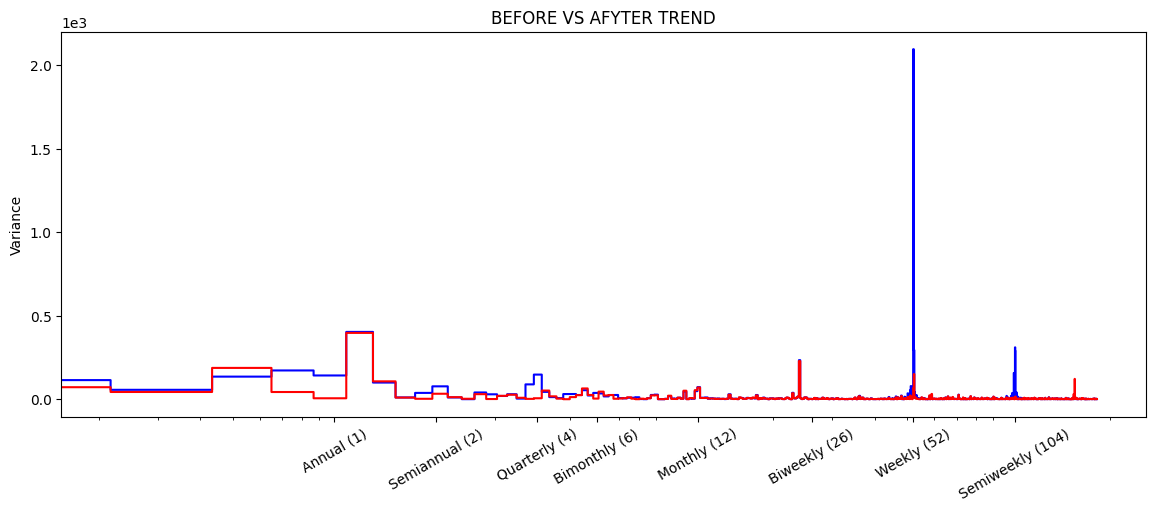

In [81]:
fig,ax=plt.subplots(figsize=(14,5))
plot_periodogram(y,ax=ax,color='blue')
plot_periodogram(y-trend_p1,ax=ax,color='red')
ax.set_title('BEFORE VS AFYTER TREND')
plt.show()

In [82]:
holidays = holidays.set_index('date').to_period('D')
holidays.head()

,type,locale,locale_name,description,transferred
date,,,,,
2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [83]:
holidays=holidays[(holidays['locale']=='National') | (holidays['locale']=='Regional')]


In [84]:
holidays=holidays[(holidays['transferred']==False)]

In [85]:
holidays['locale'].value_counts()

,count
locale,
National,166
Regional,24


In [86]:
holidays['transferred'].value_counts()

,count
transferred,
False,190


/tmp/ipykernel_4989/4279861553.py:5: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(index.to_timestamp(), y1[index], marker='.', linestyle='None', color='orange', label='Holidays')


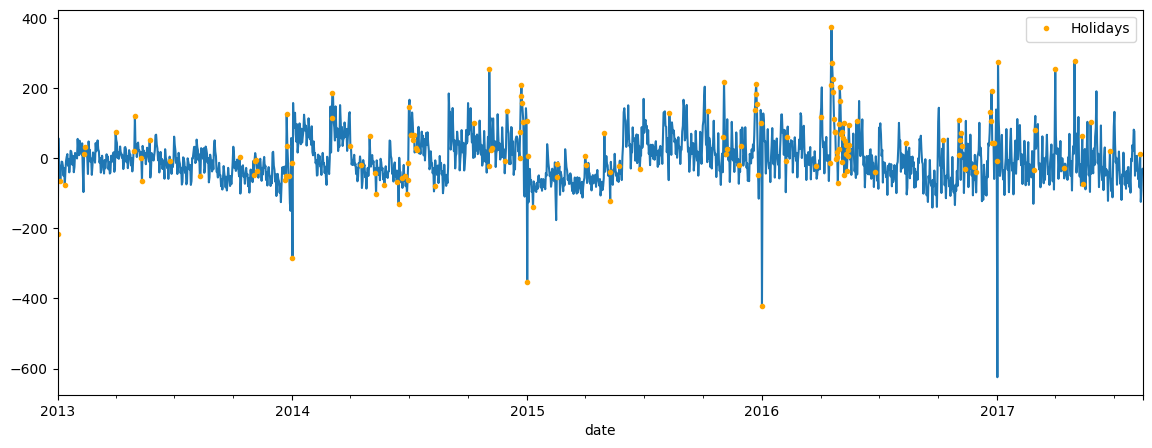

In [87]:
fig,ax=plt.subplots(figsize=(14,5))
y1=y-trend_p1
y1.plot(ax=ax)
index = holidays.index.intersection(y1.index)
ax.plot(index.to_timestamp(), y1[index], marker='.', linestyle='None', color='orange', label='Holidays')
ax.legend()
plt.show()

In [88]:
holi=pd.get_dummies(holidays['description'],prefix='holiday')
x_holidays = holi.groupby(level=0).max()
X1 = x.join(X_holidays, on='date').fillna(0.0)

In [89]:
X1.columns

Index(['const', 'trend', 's(2,7)', 's(3,7)', 's(4,7)', 's(5,7)', 's(6,7)',
       's(7,7)', 'sin(1,freq=YE-DEC)', 'cos(1,freq=YE-DEC)',
       ...
       'holiday_Terremoto Manabi+5', 'holiday_Terremoto Manabi+6',
       'holiday_Terremoto Manabi+7', 'holiday_Terremoto Manabi+8',
       'holiday_Terremoto Manabi+9', 'holiday_Traslado Batalla de Pichincha',
       'holiday_Traslado Independencia de Guayaquil',
       'holiday_Traslado Primer Grito de Independencia',
       'holiday_Traslado Primer dia del ano', 'holiday_Viernes Santo'],
      dtype='object', length=101)

In [90]:
store_sales = pd.read_csv('train.csv',
    usecols=['store_nbr', 'family', 'date', 'sales'],
    parse_dates=['date'],
    infer_datetime_format=True,
)

store_sales['date'] = store_sales.date.dt.to_period('D')

store_sales = store_sales.set_index(['store_nbr', 'family', 'date']).sort_index()

y = store_sales.unstack(['store_nbr', 'family'])

fourier = CalendarFourier(freq='M', order=4)
fourier2 = CalendarFourier(freq='A', order=10)
dp = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    seasonal=True,
    additional_terms=[fourier,fourier2],
    drop=True,
)
X = dp.in_sample()
X['is_weekend'] = X.index.dayofweek >= 5
X['NewYear'] = (X.index.dayofyear == 1)
X = X.join(X_holidays, on='date').fillna(0.0)

/tmp/ipykernel_4989/3537340547.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  store_sales = pd.read_csv('train.csv',
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [91]:
store_sales.head()

sales
store_nbr family     date             
1         AUTOMOTIVE 2013-01-01    0.0
                     2013-01-02    2.0
                     2013-01-03    3.0
                     2013-01-04    3.0
                     2013-01-05    5.0

In [92]:
y.head()

sales                                                \
store_nbr          1                                                  
family     AUTOMOTIVE BABY CARE BEAUTY BEVERAGES BOOKS BREAD/BAKERY   
date                                                                  
2013-01-01        0.0       0.0    0.0       0.0   0.0        0.000   
2013-01-02        2.0       0.0    2.0    1091.0   0.0      470.652   
2013-01-03        3.0       0.0    0.0     919.0   0.0      310.655   
2013-01-04        3.0       0.0    3.0     953.0   0.0      198.366   
2013-01-05        5.0       0.0    3.0    1160.0   0.0      301.057   

                                                 ...                    \
store_nbr                                        ...        54           
family     CELEBRATION CLEANING  DAIRY     DELI  ... MAGAZINES   MEATS   
date                                             ...                     
2013-01-01         0.0      0.0    0.0    0.000  ...       0.0   0.000   
2013-01-02         0.0   1060.0  579.0  164.069  ...       0.0  73.771   
2013-01-03         0.0    836.0  453.0  151.582  ...       0.0  50.257   
2013-01-04         0.0    827.0  460.0  131.411  ...       0.0  40.223   
2013-01-05         0.0    811.0  464.0  118.613  ...       0.0  43.431   

                                                                       \
store_nbr                                                               
family     PERSONAL CARE PET SUPPLIES PLAYERS AND ELECTRONICS POULTRY   
date                                                                    
2013-01-01           0.0          0.0                     0.0   0.000   
2013-01-02         228.0          0.0                     0.0  15.514   
2013-01-03         156.0          0.0                     0.0   4.313   
2013-01-04         146.0          0.0                     0.0  26.743   
2013-01-05         205.0          0.0                     0.0  31.118   

                                                                      
store_nbr                                                             
family     PREPARED FOODS PRODUCE SCHOOL AND OFFICE SUPPLIES SEAFOOD  
date                                                                  
2013-01-01            0.0     0.0                        0.0     0.0  
2013-01-02           61.0     0.0                        0.0     3.0  
2013-01-03            1.0     0.0                        0.0     2.0  
2013-01-04           38.0     0.0                        0.0     2.0  
2013-01-05           32.0     0.0                        0.0     1.0  

[5 rows x 1782 columns]

In [93]:
X.head()

,const,trend,"s(2,7)","s(3,7)","s(4,7)","s(5,7)","s(6,7)","s(7,7)","sin(1,freq=ME)","cos(1,freq=ME)",...,holiday_Terremoto Manabi+5,holiday_Terremoto Manabi+6,holiday_Terremoto Manabi+7,holiday_Terremoto Manabi+8,holiday_Terremoto Manabi+9,holiday_Traslado Batalla de Pichincha,holiday_Traslado Independencia de Guayaquil,holiday_Traslado Primer Grito de Independencia,holiday_Traslado Primer dia del ano,holiday_Viernes Santo
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,...,False,False,False,False,False,False,False,False,False,False
2013-01-02,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.201299,0.979530,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-03,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.394356,0.918958,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-04,1.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.571268,0.820763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-05,1.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.724793,0.688967,...,False,False,False,False,False,False,False,False,False,False


In [94]:
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
y_pred = pd.DataFrame(model.predict(X), index=X.index, columns=y.columns).clip(lower=0)

In [95]:
df_test = pd.read_csv(
    'test.csv',
    dtype={
        'store_nbr': 'category',
        'family': 'category',
        'onpromotion': 'uint32',
    },
    parse_dates=['date'],
    infer_datetime_format=True,
)
df_test['date'] = df_test.date.dt.to_period('D')
df_test = df_test.set_index(['store_nbr', 'family', 'date']).sort_index()

X_test = dp.out_of_sample(steps=160)
X_test.index.name = 'date'
X_test['is_weekend'] = (X_test.index.dayofweek >= 5).astype(int)
X_test['NewYear'] = (X_test.index.dayofyear == 1).astype(int)
X_test = X_test.join(X_holidays, on='date').fillna(0.0)
X_test.info()


<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 160 entries, 2017-08-16 to 2018-01-22
Freq: D
Columns: 114 entries, const to holiday_Viernes Santo
dtypes: float64(36), int64(2), object(76)
memory usage: 143.8+ KB


/tmp/ipykernel_4989/1789983795.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_test = pd.read_csv(


In [96]:
y_fore = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns).clip(lower=0)

In [97]:
y_fore.tail()

sales                                                          \
store_nbr          1                                                            
family     AUTOMOTIVE BABY CARE    BEAUTY    BEVERAGES     BOOKS BREAD/BAKERY   
date                                                                            
2018-01-18   4.919287       0.0  3.342934  2849.101247  0.569991   475.476072   
2018-01-19   5.087435       0.0  3.194452  2837.489861  0.532995   485.684564   
2018-01-20   4.149951       0.0  2.530723  2500.764189  0.473327   370.448702   
2018-01-21   4.356459       0.0  2.392800  2394.222284  0.528644   366.599234   
2018-01-22   4.937281       0.0  3.136961  2716.542990  0.538077   461.681220   

                                                            ...            \
store_nbr                                                   ...        54   
family     CELEBRATION    CLEANING       DAIRY        DELI  ... MAGAZINES   
date                                                        ...             
2018-01-18   30.586629  783.084596  937.373317  156.397880  ...  1.107022   
2018-01-19   23.316486  830.204555  944.502604  166.249526  ...  1.310555   
2018-01-20   17.117288  543.186168  797.614885  127.280067  ...  1.737062   
2018-01-21   14.645232  550.140898  761.841693  128.000422  ...  1.759190   
2018-01-22   17.582649  785.606266  896.235736  162.804439  ...  1.350355   

                                                                          \
store_nbr                                                                  
family          MEATS PERSONAL CARE PET SUPPLIES PLAYERS AND ELECTRONICS   
date                                                                       
2018-01-18  61.446219    207.232645     0.197984                4.738111   
2018-01-19  58.677194    186.773392     0.233113                4.856488   
2018-01-20  67.665216    276.537370     0.261105                5.900888   
2018-01-21  66.989628    278.783468     0.318222                5.979150   
2018-01-22  55.383658    194.149395     0.315083                4.898268   

                                                                             \
store_nbr                                                                     
family        POULTRY PREPARED FOODS     PRODUCE SCHOOL AND OFFICE SUPPLIES   
date                                                                          
2018-01-18  60.941013      95.566195  831.432493                   1.294913   
2018-01-19  56.713021      87.712225  828.679814                   1.287224   
2018-01-20  77.128023      99.266712  903.319322                   1.591874   
2018-01-21  70.278720      99.512322  937.608025                   1.796279   
2018-01-22  60.986854      92.803586  863.184240                   1.659148   

                      
store_nbr             
family       SEAFOOD  
date                  
2018-01-18  1.378931  
2018-01-19  1.272956  
2018-01-20  1.582869  
2018-01-21  1.463003  
2018-01-22  1.737894  

[5 rows x 1782 columns]

In [98]:
y_pred=y_pred.stack([2, 1], future_stack=True)
y_fore=y_fore.stack([2, 1], future_stack=True)

In [99]:
y_pred.tail()

sales
date       family                     store_nbr            
2017-08-15 POULTRY                    54          60.583847
           PREPARED FOODS             54          83.296961
           PRODUCE                    54         718.853982
           SCHOOL AND OFFICE SUPPLIES 54           0.916325
           SEAFOOD                    54           1.989446

In [100]:
y.tail()

sales                                                \
store_nbr          1                                                  
family     AUTOMOTIVE BABY CARE BEAUTY BEVERAGES BOOKS BREAD/BAKERY   
date                                                                  
2017-08-11        1.0       0.0    1.0    1006.0   0.0    145.60700   
2017-08-12        6.0       0.0    3.0    1659.0   0.0    243.22000   
2017-08-13        1.0       0.0    1.0     803.0   0.0    136.67900   
2017-08-14        1.0       0.0    6.0    2201.0   0.0    346.03800   
2017-08-15        4.0       0.0    4.0    1942.0   0.0    329.54102   

                                                 ...                       \
store_nbr                                        ...        54              
family     CELEBRATION CLEANING  DAIRY     DELI  ... MAGAZINES      MEATS   
date                                             ...                        
2017-08-11         4.0    341.0  343.0   64.302  ...       0.0  50.756000   
2017-08-12         3.0    351.0  526.0   99.488  ...       1.0  53.079002   
2017-08-13         1.0    169.0  266.0   47.770  ...       3.0  67.435000   
2017-08-14         4.0    571.0  699.0  154.578  ...       1.0  64.224000   
2017-08-15        21.0    703.0  602.0  116.402  ...       2.0  57.842000   

                                                                          \
store_nbr                                                                  
family     PERSONAL CARE PET SUPPLIES PLAYERS AND ELECTRONICS    POULTRY   
date                                                                       
2017-08-11         155.0          0.0                     0.0  80.759000   
2017-08-12         169.0          0.0                     4.0  91.671000   
2017-08-13         244.0          0.0                     2.0  79.062996   
2017-08-14         200.0          0.0                     1.0  56.155000   
2017-08-15         169.0          0.0                     2.0  59.619000   

                                                                       
store_nbr                                                              
family     PREPARED FOODS  PRODUCE SCHOOL AND OFFICE SUPPLIES SEAFOOD  
date                                                                   
2017-08-11           54.0  546.250                        0.0     0.0  
2017-08-12           81.0  696.920                        0.0     1.0  
2017-08-13           91.0  877.304                        0.0     2.0  
2017-08-14          147.0  585.615                        0.0     0.0  
2017-08-15           94.0  915.371                        0.0     3.0  

[5 rows x 1782 columns]

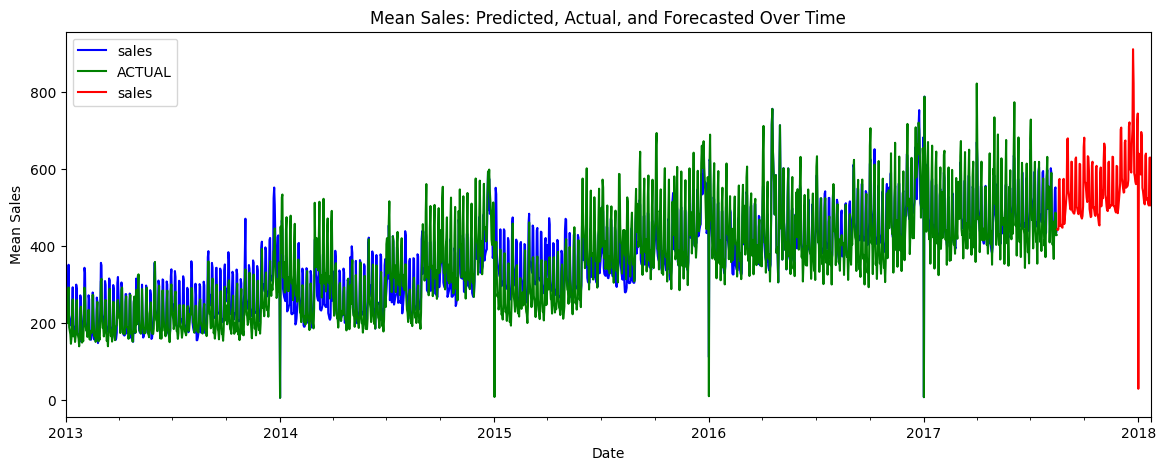

In [101]:
fig,ax=plt.subplots(figsize=(14,5))
y_pred.groupby(level='date').mean().plot(ax=ax, label='PREDICT', color='b')
y.mean(axis=1).plot(ax=ax, label='ACTUAL', color='g')
y_fore.groupby(level='date').mean().plot(ax=ax, label='FORECAST', color='r')
ax.set_title('Mean Sales: Predicted, Actual, and Forecasted Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sales')
ax.legend()
plt.show()

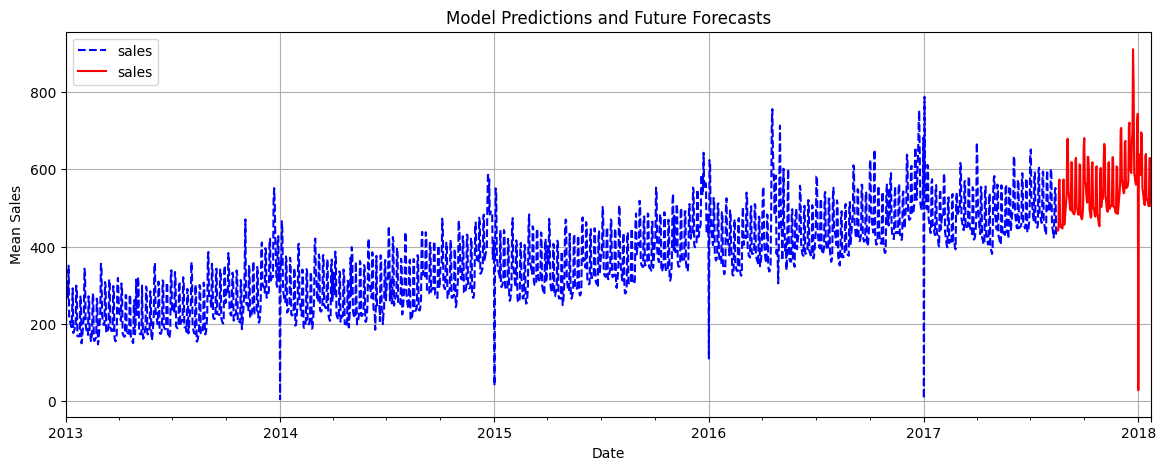

In [102]:
fig, ax = plt.subplots(figsize=(14, 5))

y_pred.groupby(level='date').mean().plot(ax=ax, label='Model Predictions', color='blue', linestyle='--')
y_fore.groupby(level='date').mean().plot(ax=ax, label='Future Forecasts', color='red')

ax.set_title('Model Predictions and Future Forecasts')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sales')
ax.legend()
plt.grid(True)
plt.show()

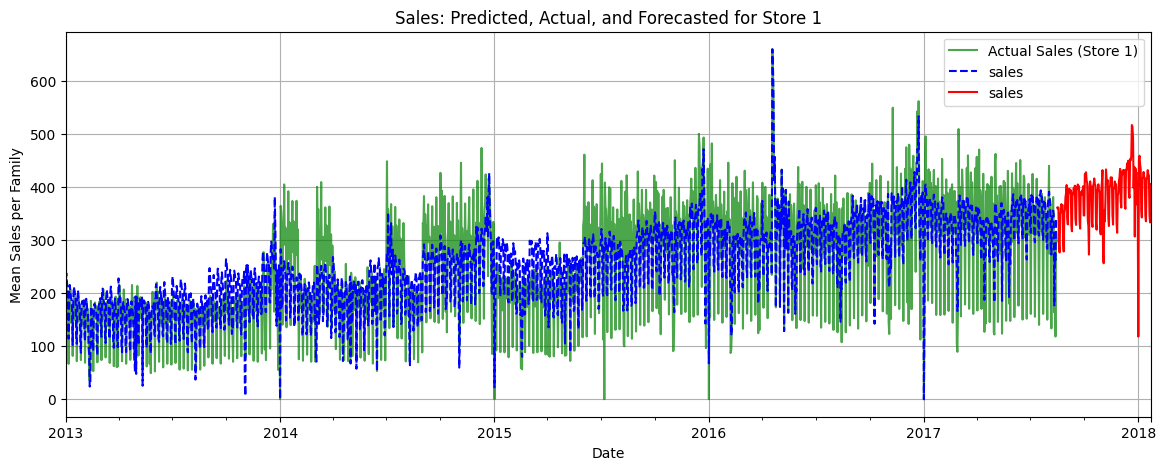

In [103]:
selected_store_nbr = 1

# Calculate mean sales for the selected store across all families
y_actual_store = y.loc[:, (slice(None), selected_store_nbr, slice(None))].droplevel(0, axis=1).mean(axis=1)

# Calculate mean predictions and forecasts for the selected store across all families
y_pred_store = y_pred.xs(selected_store_nbr, level='store_nbr').groupby(level='date').mean()
y_fore_store = y_fore.xs(selected_store_nbr, level='store_nbr').groupby(level='date').mean()

fig, ax = plt.subplots(figsize=(14, 5))

y_actual_store.plot(ax=ax, label=f'Actual Sales (Store {selected_store_nbr})', color='green', alpha=0.7)
y_pred_store.plot(ax=ax, label=f'Predicted Sales (Store {selected_store_nbr})', color='blue', linestyle='--')
y_fore_store.plot(ax=ax, label=f'Forecasted Sales (Store {selected_store_nbr})', color='red')

ax.set_title(f'Sales: Predicted, Actual, and Forecasted for Store {selected_store_nbr}')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Sales per Family')
ax.legend()
plt.grid(True)
plt.show()